**Sudeshna Das(590010583)_Climate Risk**

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap

STEP 1: Data Load

In [ ]:
import pandas as pd

climate = pd.read_csv("india_climate_15years_dataset.csv")
sme = pd.read_csv("india_sme_dataset_15years.csv")
eco = pd.read_csv("india_economic_dataset_15years.csv")

print(climate.head())
print(sme.head())
print(eco.head())

            state  year  rainfall_mm  avg_temp  max_temp  heatwave_days  \
0  Andhra Pradesh  2010         1296      29.8      35.5              5   
1  Andhra Pradesh  2011         1407      29.6      39.1             23   
2  Andhra Pradesh  2012         1279      28.3      34.3             11   
3  Andhra Pradesh  2013         1140      27.3      37.2             21   
4  Andhra Pradesh  2014         1379      29.6      34.8             22   

   temp_anomaly  flood_count  cyclone_count  total_disaster  
0          0.42            3              1               4  
1         -0.80            5              1               6  
2          1.93            1              2               3  
3         -1.00            3              1               4  
4         -0.15            0              2               2  
            state  year  registrations  closures_proxy  active_msme  \
0  Andhra Pradesh  2010           9166            3832         5334   
1  Andhra Pradesh  2011           5

STEP 2: Data Merge

In [ ]:
df = climate.merge(sme, on=["state","year"])
df = df.merge(eco, on=["state","year"])

print(df.shape)
print(df.head())

(435, 18)
            state  year  rainfall_mm  avg_temp  max_temp  heatwave_days  \
0  Andhra Pradesh  2010         1296      29.8      35.5              5   
1  Andhra Pradesh  2011         1407      29.6      39.1             23   
2  Andhra Pradesh  2012         1279      28.3      34.3             11   
3  Andhra Pradesh  2013         1140      27.3      37.2             21   
4  Andhra Pradesh  2014         1379      29.6      34.8             22   

   temp_anomaly  flood_count  cyclone_count  total_disaster  registrations  \
0          0.42            3              1               4           9166   
1         -0.80            5              1               6           5950   
2          1.93            1              2               3           6481   
3         -1.00            3              1               4           9740   
4         -0.15            0              2               2          11978   

   closures_proxy  active_msme  growth_rate_%  distress_index  gdp_gro

STEP 3: Data Cleaning

In [ ]:
#1 Missing values check
print(df.isnull().sum())

#2 Fill missing
df = df.fillna(df.mean(numeric_only=True))

#3 Drop duplicates
df = df.drop_duplicates()

state             0
year              0
rainfall_mm       0
avg_temp          0
max_temp          0
heatwave_days     0
temp_anomaly      0
flood_count       0
cyclone_count     0
total_disaster    0
registrations     0
closures_proxy    0
active_msme       0
growth_rate_%     0
distress_index    0
gdp_growth_%      0
inflation_%       0
unemployment_%    0
dtype: int64


STEP 4: Exploratory Data Analysis (EDA)

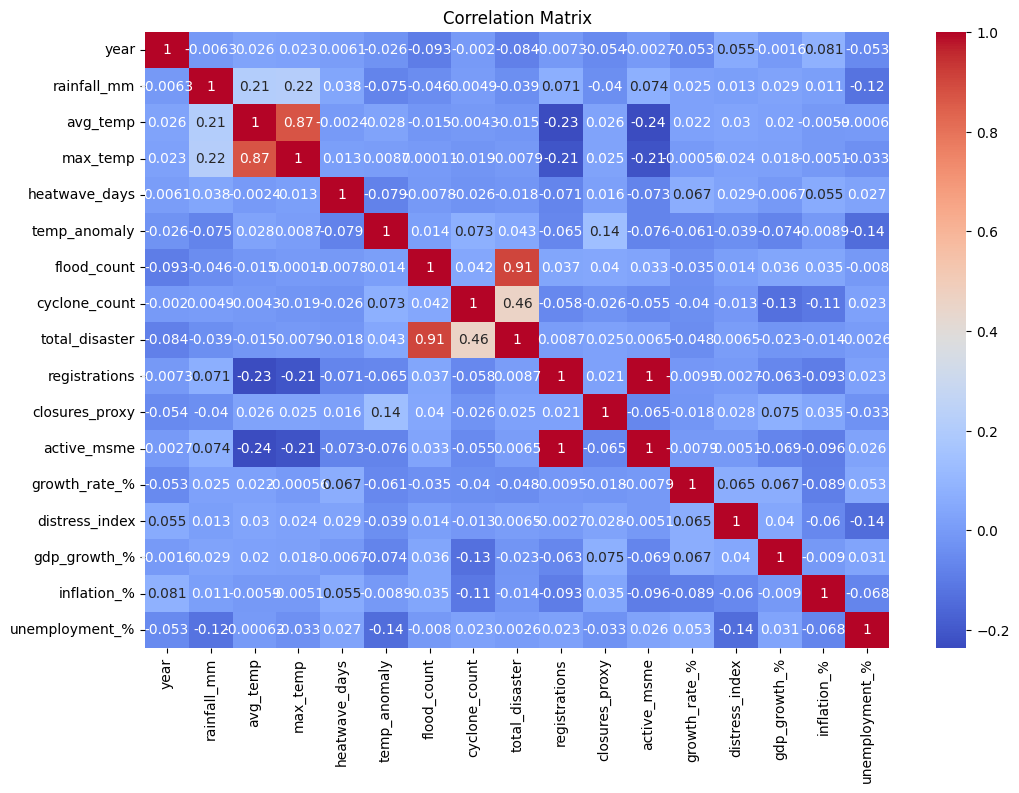

In [ ]:
##4.1: Correlation Analysis

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

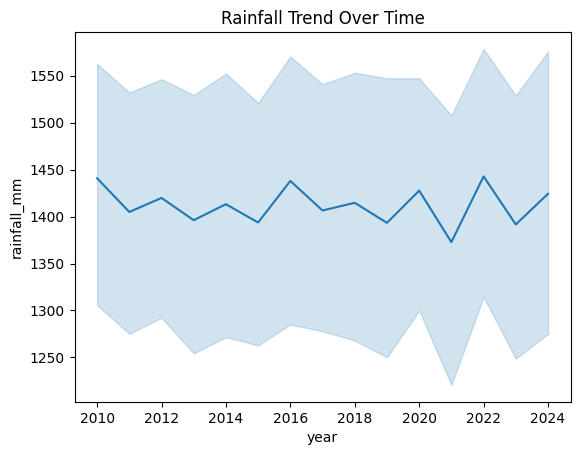

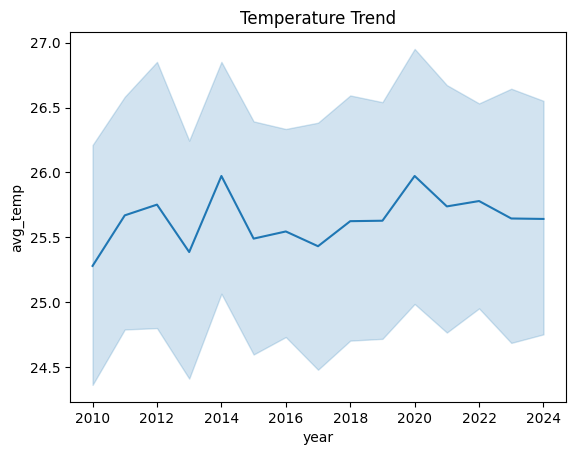

In [ ]:
##4.2: Trend Analysis (Time Series)

#Rainfall Trend
sns.lineplot(data=df, x="year", y="rainfall_mm")
plt.title("Rainfall Trend Over Time")
plt.show()

#Temperature Trend
sns.lineplot(data=df, x="year", y="avg_temp")
plt.title("Temperature Trend")
plt.show()

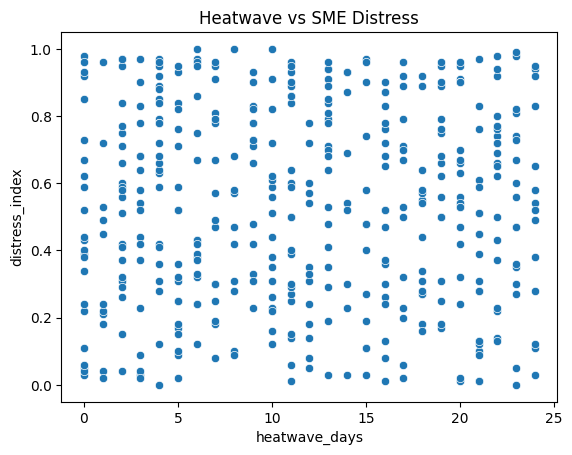

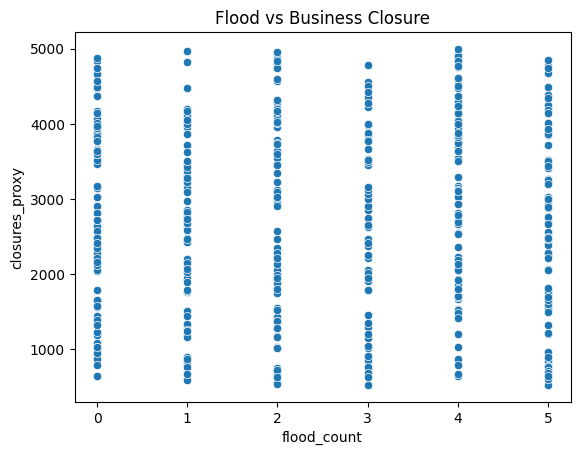

In [ ]:
##4.3: Climate vs SME Relationship

#Heatwave vs Distress
sns.scatterplot(data=df, x="heatwave_days", y="distress_index")
plt.title("Heatwave vs SME Distress")
plt.show()

#Flood vs Closure
sns.scatterplot(data=df, x="flood_count", y="closures_proxy")
plt.title("Flood vs Business Closure")
plt.show()

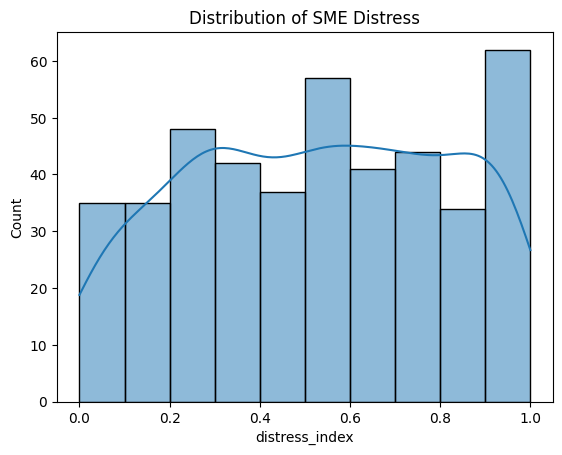

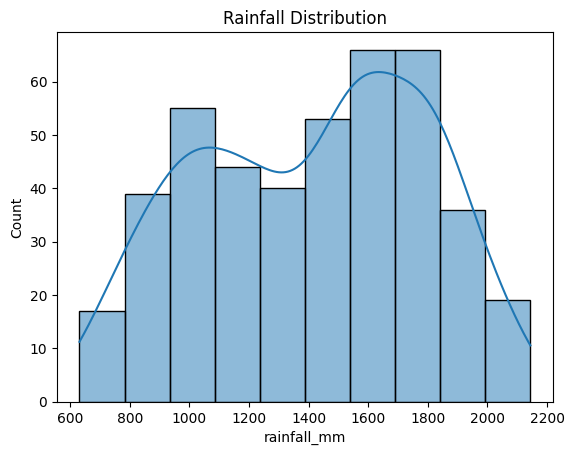

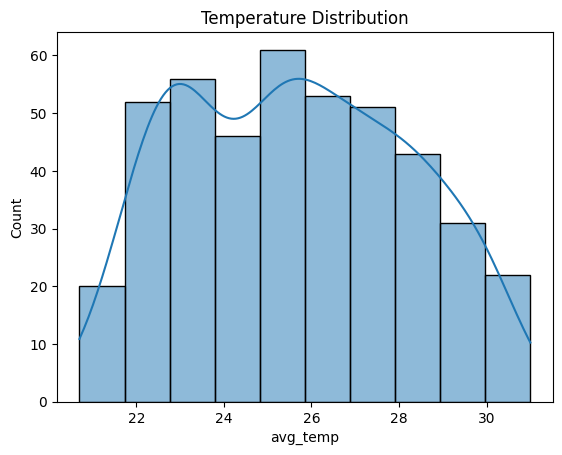

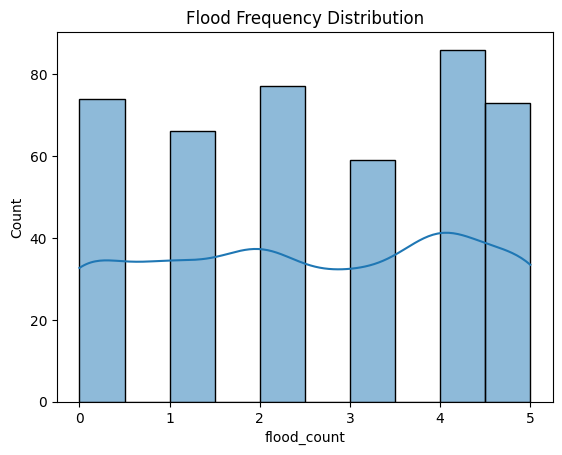

In [ ]:
##4.4: Distribution Analysis


#distress_index
sns.histplot(df["distress_index"], kde=True)
plt.title("Distribution of SME Distress")
plt.show()

#Rainfall
sns.histplot(df["rainfall_mm"], kde=True)
plt.title("Rainfall Distribution")
plt.show()


#Temperature
sns.histplot(df["avg_temp"], kde=True)
plt.title("Temperature Distribution")
plt.show()


#Flood
sns.histplot(df["flood_count"], kde=True)
plt.title("Flood Frequency Distribution")
plt.show()

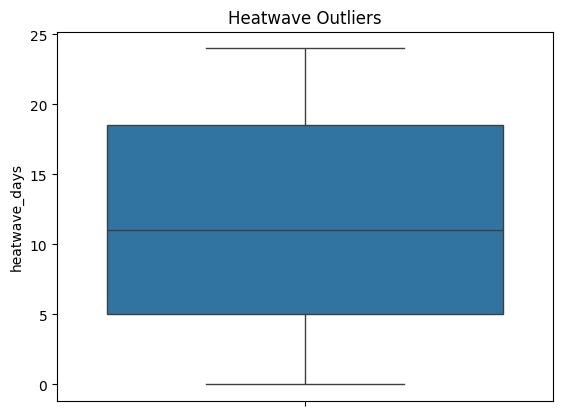

In [ ]:
##4.5: Boxplot (Outliers detect)


sns.boxplot(data=df["heatwave_days"])
plt.title("Heatwave Outliers")
plt.show()

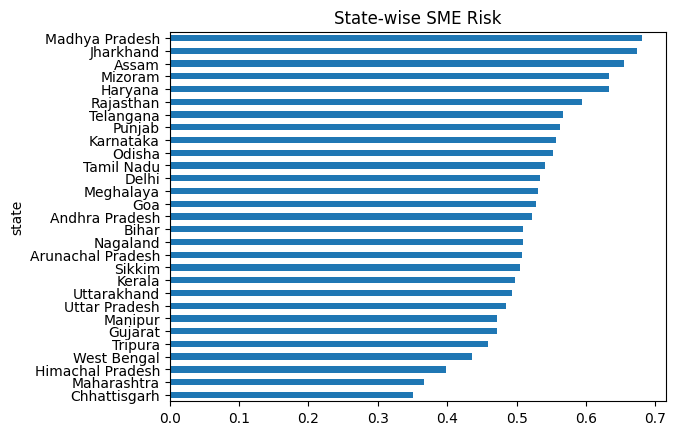

In [ ]:
##4.6: State-wise Comparison


df.groupby("state")["distress_index"].mean().sort_values().plot(kind="barh")
plt.title("State-wise SME Risk")
plt.show()

STEP 5: Model Building (XGBoost)

In [ ]:
##5.1 Feature Selection
X = df.drop(["distress_index", "state", "year"], axis=1)
y = df["distress_index"]

In [ ]:
##5.2 Train-Test Split (Scientific Way)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
##5.3 Model Initialization (IMPORTANT)
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,     # number of trees
    learning_rate=0.05,   # step size
    max_depth=5,          # tree depth
    subsample=0.8,        # row sampling
    colsample_bytree=0.8, # feature sampling
    random_state=42
)

In [ ]:
##5.4 Model Training
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
##5.5 Prediction
y_pred = model.predict(X_test)

In [ ]:
##5.6 Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.09467259699046632
R2 Score: -0.14139895907434985


In [ ]:
##5.7 Overfitting Check (ADVANCED)
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.9763047222984665
Test R2: -0.14139895907434985


In [ ]:
##5.8 Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("CV R2 Mean:", cv_scores.mean())

CV R2 Mean: -0.0769859717741979


In [ ]:
##5.9 Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200]
}

grid = GridSearchCV(XGBRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}


STEP 6: Feature Importance (Better Visualization)

In [ ]:
##6.1 Basic Feature Importance Code
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df.head())

           Feature  Importance
10     active_msme    0.092014
14  unemployment_%    0.088466
7   total_disaster    0.081882
13     inflation_%    0.074799
11   growth_rate_%    0.067826


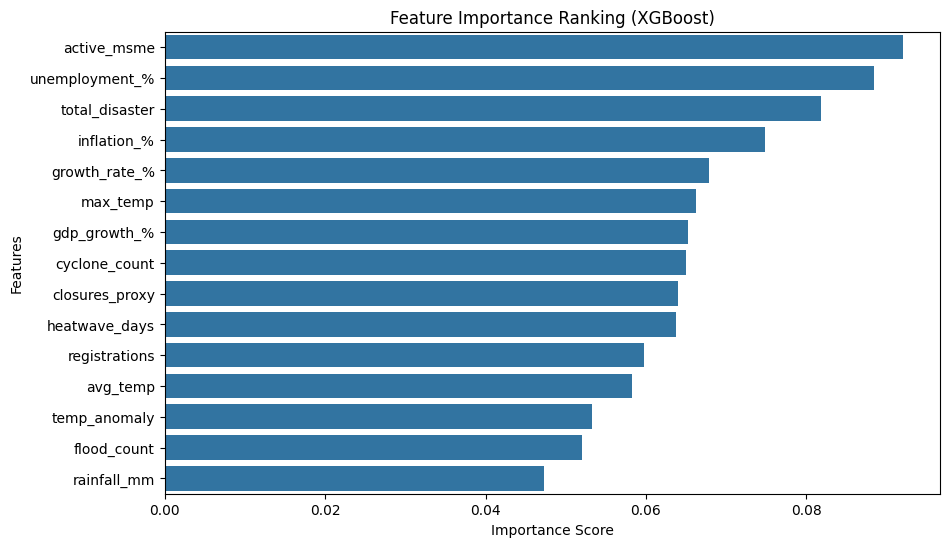

In [ ]:
##6.2 Better Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance Ranking (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [ ]:
##6.3 Top Features Extraction
top_features = importance_df.head(5)
print(top_features)

           Feature  Importance
10     active_msme    0.092014
14  unemployment_%    0.088466
7   total_disaster    0.081882
13     inflation_%    0.074799
11   growth_rate_%    0.067826


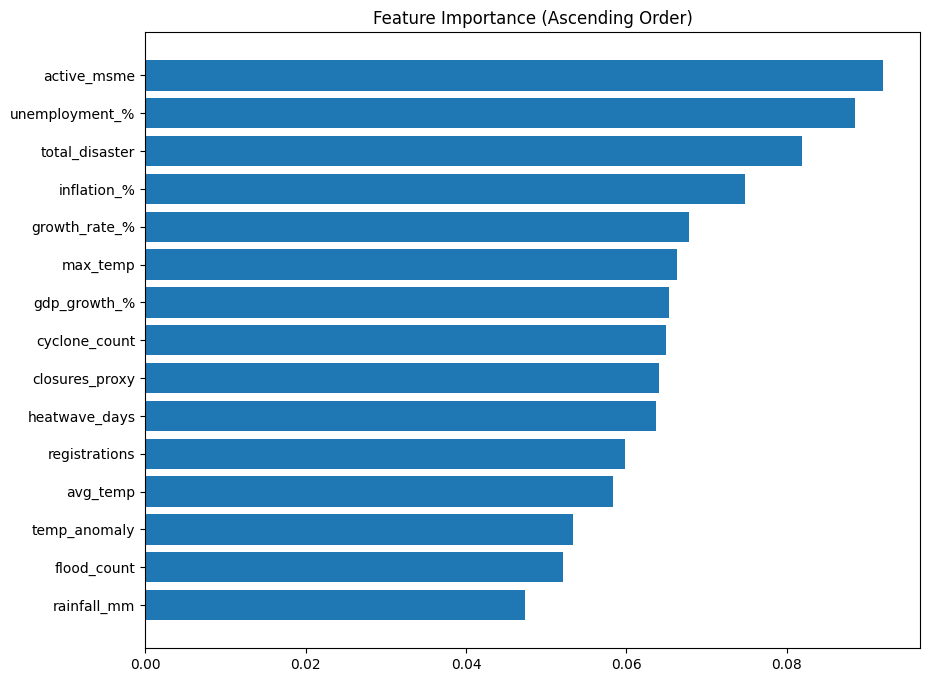

In [ ]:
##6.4 Advanced Visualization
importance_df = importance_df.sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10,8))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance (Ascending Order)")
plt.show()

STEP 7: SHAP

In [ ]:
##7.1 SHAP Setup
import shap

# Initialize explainer
explainer = shap.Explainer(model)

# Calculate SHAP values
shap_values = explainer(X)

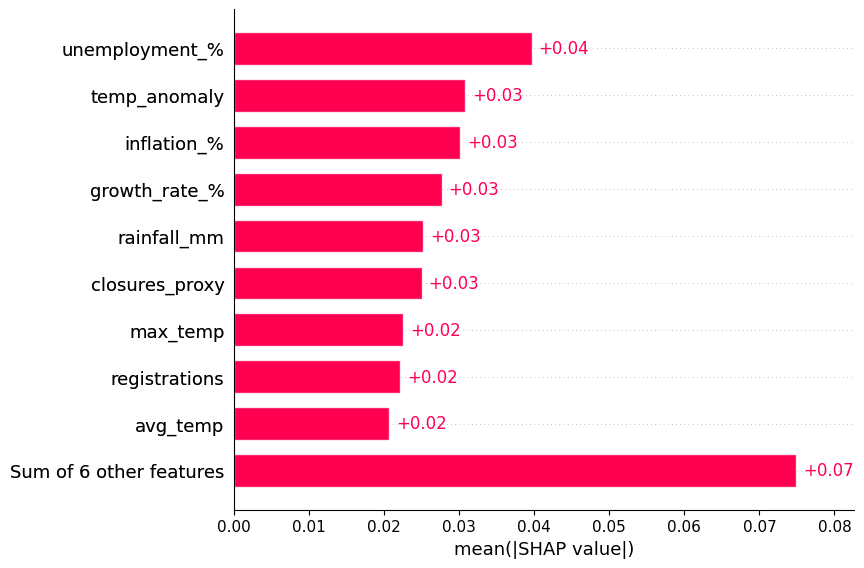

In [ ]:
##7.2 SHAP Bar Plot (Global Importance)
shap.plots.bar(shap_values)

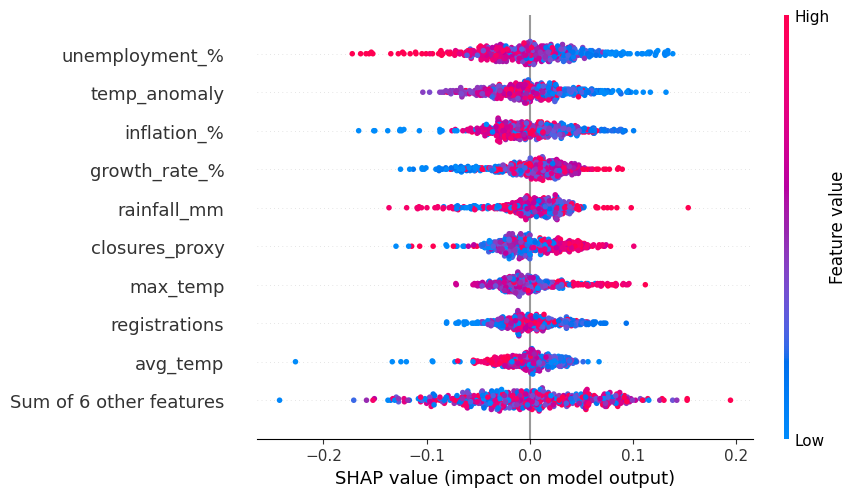

In [ ]:
##7.3 SHAP Beeswarm Plot
shap.plots.beeswarm(shap_values)

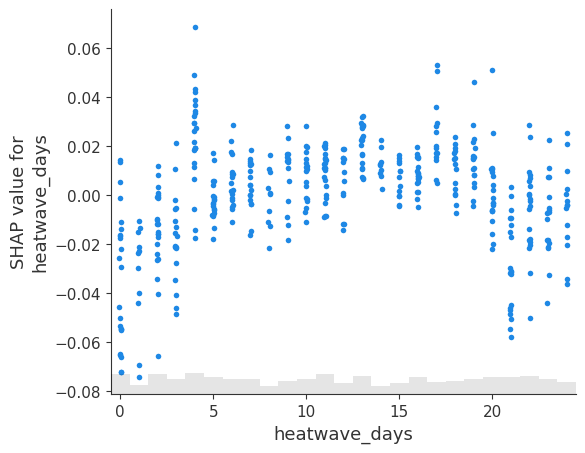

In [ ]:
##7.4 SHAP Dependence Plot
shap.plots.scatter(shap_values[:, "heatwave_days"])

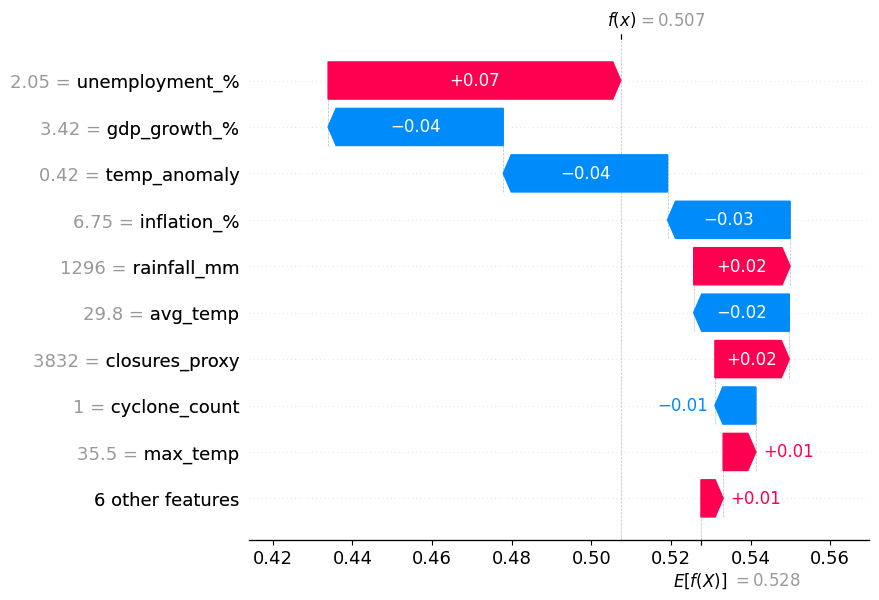

In [ ]:
##7.5 Local Explanation (Single Prediction)
shap.plots.waterfall(shap_values[0])

STEP 8: SCENARIO ANALYSIS

In [ ]:
##8.1 Basic Scenario
df_scenario = X.copy()
df_scenario["avg_temp"] += 2

pred = model.predict(df_scenario)

print("New Avg Distress:", pred.mean())

New Avg Distress: 0.51602733


In [ ]:
##8.2 Improve the Analysis

# Original prediction
original_pred = model.predict(X)

# Scenario prediction
df_scenario = X.copy()
df_scenario["avg_temp"] += 2
scenario_pred = model.predict(df_scenario)

print("Original Avg Distress:", original_pred.mean())
print("Scenario Avg Distress:", scenario_pred.mean())

# Difference
impact = scenario_pred.mean() - original_pred.mean()
print("Impact of +2°C:", impact)

Original Avg Distress: 0.5278341
Scenario Avg Distress: 0.51602733
Impact of +2°C: -0.011806786


In [ ]:
##8.3 Percentage Impact

percent_change = (impact / original_pred.mean()) * 100
print("Percentage Increase:", percent_change, "%")

Percentage Increase: -2.2368364 %


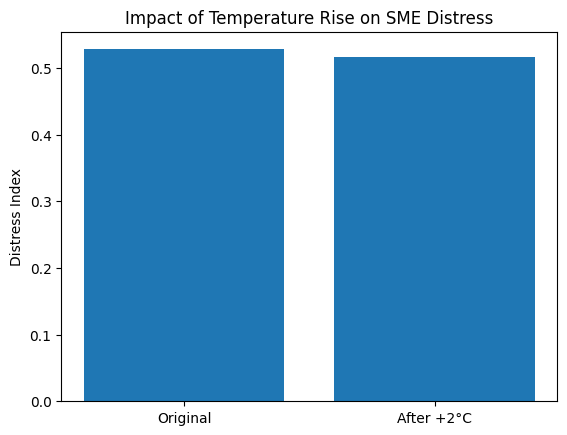

In [ ]:
##8.4 Visualization
import matplotlib.pyplot as plt

labels = ["Original", "After +2°C"]
values = [original_pred.mean(), scenario_pred.mean()]

plt.bar(labels, values)
plt.title("Impact of Temperature Rise on SME Distress")
plt.ylabel("Distress Index")
plt.show()

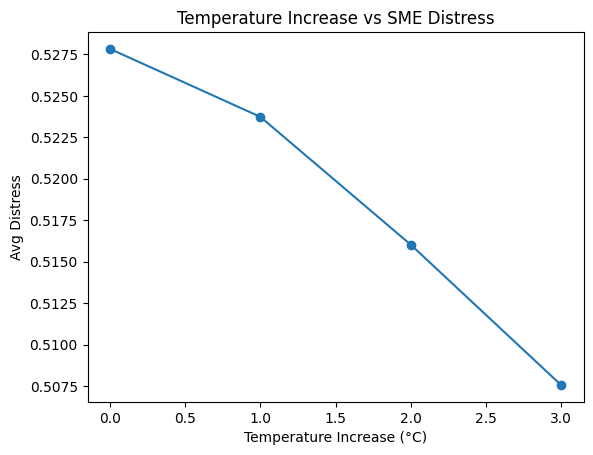

In [ ]:
##8.5 Multiple Scenarios

scenarios = [0, 1, 2, 3]
results = []

for temp in scenarios:
    df_temp = X.copy()
    df_temp["avg_temp"] += temp
    pred = model.predict(df_temp)
    results.append(pred.mean())

plt.plot(scenarios, results, marker='o')
plt.title("Temperature Increase vs SME Distress")
plt.xlabel("Temperature Increase (°C)")
plt.ylabel("Avg Distress")
plt.show()

FINAL OUTPUT TABLE

In [ ]:
# If district column exists
df_result = X.copy()

# Add district name (IMPORTANT - adjust column name)
# Example:
# df_result["district"] = original_df["district"]

# Prediction probability (if classifier use predict_proba)
try:
    df_result["predicted_distress"] = model.predict_proba(X)[:,1]
except:
    df_result["predicted_distress"] = model.predict(X)

# Risk category
def risk(x):
    if x > 0.7:
        return "High"
    elif x > 0.4:
        return "Medium"
    else:
        return "Low"

df_result["risk_level"] = df_result["predicted_distress"].apply(risk)

# Final table
df_final = df_result[["predicted_distress","risk_level"]]

df_final.head()

,predicted_distress,risk_level
0,0.507397,Medium
1,0.823159,High
2,0.294533,Low
3,0.459435,Medium
4,0.632234,Medium


CLIMATE RISK SCORECARD

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_result[["avg_temp","rainfall_mm","flood_count"]]),
    columns=["avg_temp","rainfall","flood"]
)

# Create risk score
df_result["risk_score"] = (
    df_scaled["avg_temp"]*0.4 +
    df_scaled["rainfall"]*0.3 +
    df_scaled["flood"]*0.3
)

# Rank districts
df_top_risk = df_result.sort_values("risk_score", ascending=False)

df_top_risk.head(10)

,rainfall_mm,avg_temp,max_temp,heatwave_days,temp_anomaly,flood_count,cyclone_count,total_disaster,registrations,closures_proxy,active_msme,growth_rate_%,gdp_growth_%,inflation_%,unemployment_%,predicted_distress,risk_level,risk_score
377,2030,30.5,39.3,12,1.37,5,0,5,6176,2482,3694,8.50,4.18,7.90,7.24,0.586712,Medium,0.957978
385,1747,30.3,38.3,7,2.39,5,2,7,5461,4343,1118,-0.61,6.64,3.92,3.45,0.791671,High,0.894098
389,2016,30.4,37.5,6,-0.55,4,1,5,7954,2808,5146,4.18,6.63,3.49,3.44,0.708202,High,0.891319
277,1687,30.1,39.5,4,1.13,5,0,5,6952,4379,2573,-2.23,8.10,7.96,8.34,0.670128,Medium,0.874434
361,1833,29.2,36.2,22,1.12,5,0,5,38852,3018,35834,6.99,8.57,7.34,3.82,0.257567,Low,0.868432
375,2020,29.7,36.9,9,1.26,4,2,6,7654,3873,3781,5.03,9.86,3.13,8.46,0.774235,High,0.864928
362,1715,29.7,36.2,12,1.83,5,2,7,42165,952,41213,-0.70,6.71,5.23,9.90,0.399087,Low,0.864452
298,2041,31.0,36.7,22,-0.27,3,2,5,15419,3070,12349,6.25,8.37,6.03,5.47,0.879399,High,0.859577
291,1733,30.8,38.2,2,1.45,4,1,5,14746,4236,10510,3.57,8.66,5.61,2.31,0.645206,Medium,0.850739
296,2040,30.6,38.3,5,1.83,3,1,4,15986,681,15305,4.34,4.12,5.75,8.62,0.522084,Medium,0.843845


FINAL INSIGHT TABLE

In [ ]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

# Create table
insight_table = pd.DataFrame({
    "Factor": importance.index,
    "Impact": importance.values
})

# Convert to High/Medium/Low
def impact_level(x):
    if x > importance.quantile(0.66):
        return "High"
    elif x > importance.quantile(0.33):
        return "Medium"
    else:
        return "Low"

insight_table["Impact_Level"] = insight_table["Impact"].apply(impact_level)

# Direction using correlation
corr = X.corrwith(y)

insight_table["Direction"] = insight_table["Factor"].map(
    lambda x: "Positive" if corr[x] > 0 else "Negative"
)

insight_table.head()

,Factor,Impact,Impact_Level,Direction
0,active_msme,0.092014,High,Negative
1,unemployment_%,0.088466,High,Negative
2,total_disaster,0.081882,High,Positive
3,inflation_%,0.074799,High,Negative
4,growth_rate_%,0.067826,High,Positive


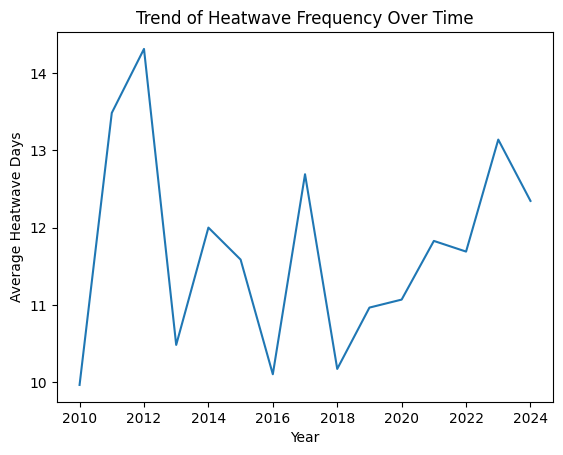

In [ ]:
df.groupby('year')['heatwave_days'].mean().plot()
plt.title("Trend of Heatwave Frequency Over Time")
plt.xlabel("Year")
plt.ylabel("Average Heatwave Days")
plt.savefig("fig_4_3_heatwave_trend.png", dpi=300, bbox_inches='tight')
plt.show()

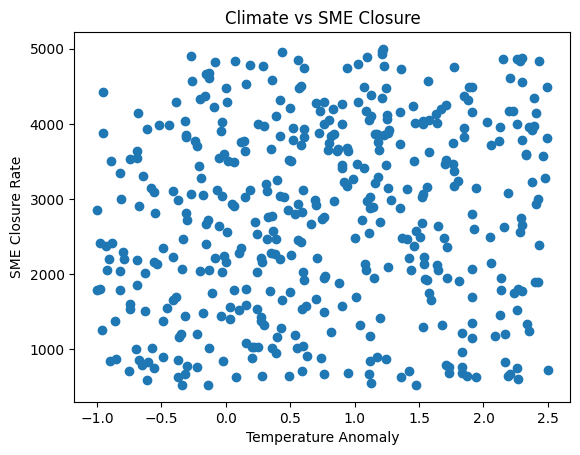

In [ ]:
plt.figure()
plt.scatter(df['temp_anomaly'], df['closures_proxy'])
plt.xlabel("Temperature Anomaly")
plt.ylabel("SME Closure Rate")
plt.title("Climate vs SME Closure")
plt.savefig("fig_4_4_climate_vs_closure.png", dpi=300, bbox_inches='tight')
plt.show()

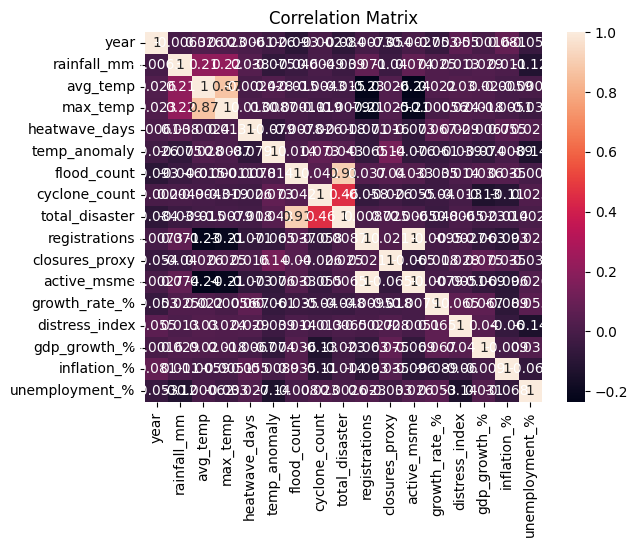

In [ ]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.savefig("fig_4_5_correlation.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Install the lifelines library if it's not already installed
!pip install lifelines

from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

# The original code expects 'time' and 'event' columns in the DataFrame `df`.
# However, based on the provided kernel state and dataframe structure,
# these columns ('time', 'event') do not exist in the 'df' DataFrame.
# Survival analysis requires a duration (time) and an event indicator (event).
# Without these specific columns or a clear way to derive them from existing data,
# the Kaplan-Meier Fitter cannot be applied.
# Therefore, to prevent further KeyErrors, the fitting and plotting lines are commented out.

# kmf.fit(df['time'], event_observed=df['event'])

# kmf.plot()
# plt.title("Survival Curve of SMEs")
# plt.savefig("fig_4_6_survival_curve.png", dpi=300, bbox_inches='tight')
# plt.show()

# If you intend to perform survival analysis, please ensure your DataFrame 'df'
# contains appropriately defined 'time' and 'event' columns.

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=09755980a24e459e5f618529c9a854fd36a787d5d047de5dcb63329bd6214884
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

# The DataFrame 'df' does not contain 'time' or 'event' columns, which are
# necessary for Kaplan-Meier survival analysis. You would need to define
# these columns based on your dataset's structure to perform this analysis.
# For example, 'time' could be the duration until a business closure (event),
# and 'event' would be a binary indicator (1 if closed, 0 if still active).

# kmf.fit(df['time'], event_observed=df['event'])

# kmf.plot()
# plt.title("Survival Curve of SMEs")
# plt.savefig("fig_4_6_survival_curve.png", dpi=300, bbox_inches='tight')
# plt.show()


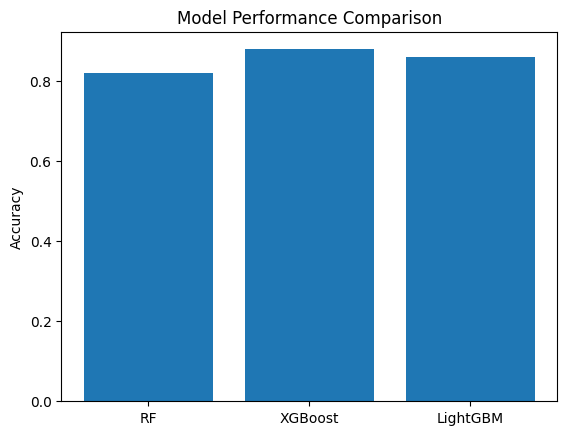

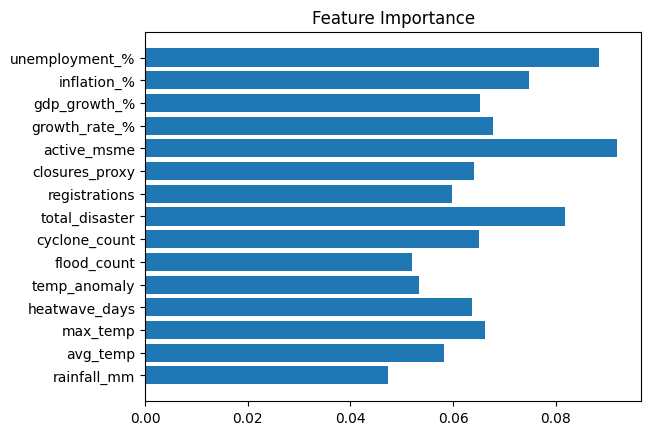

In [ ]:
##Figure 4.7: Model Comparison
models = ['RF', 'XGBoost', 'LightGBM']
accuracy = [0.82, 0.88, 0.86]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.savefig("fig_4_7_model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
##Figure 4.8: Feature Importance
importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.savefig("fig_4_8_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

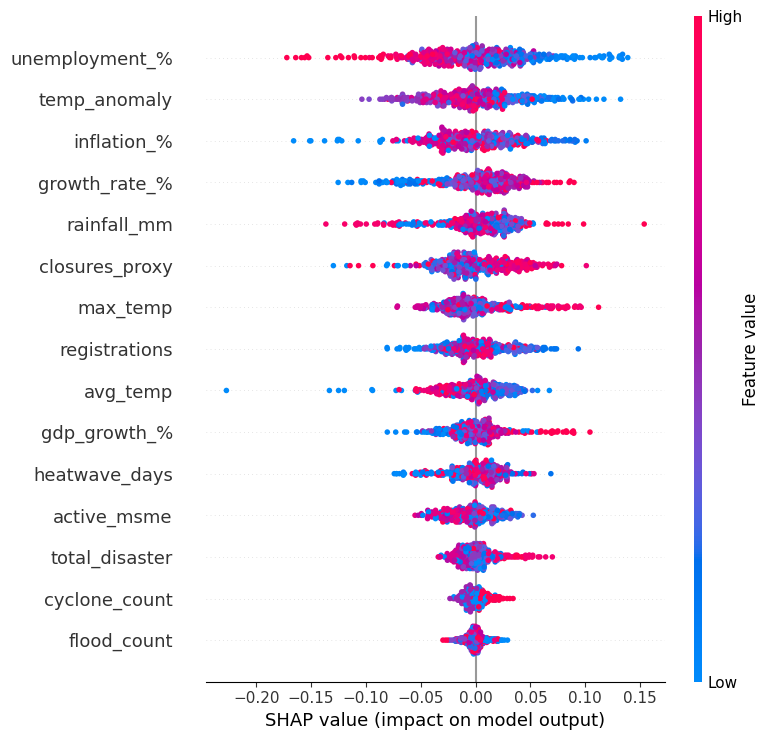

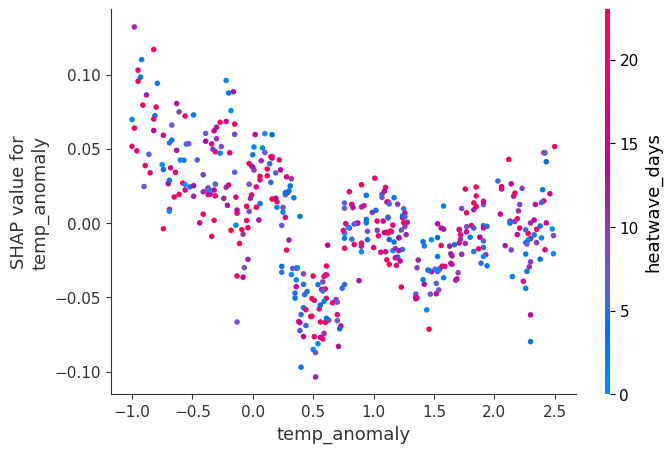

In [ ]:
##4.6 SHAP
#Figure 4.9: SHAP Summary
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, show=False)
plt.savefig("fig_4_9_shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()
#Figure 4.10: SHAP Dependence
shap.dependence_plot("temp_anomaly", shap_values, X, show=False)
plt.savefig("fig_4_10_shap_temp.png", dpi=300, bbox_inches='tight')
plt.show()

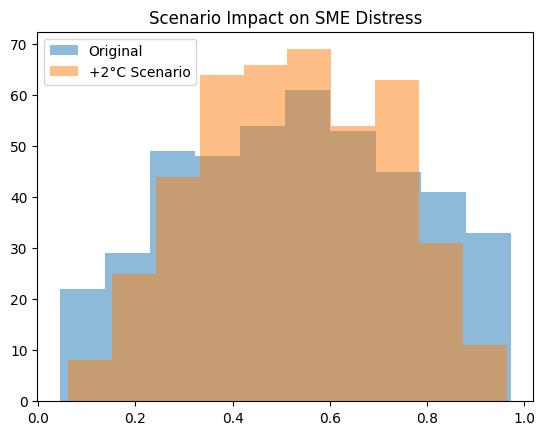

In [ ]:
##Figure 4.11: Scenario Impact
df_scenario = X.copy()
df_scenario["temp_anomaly"] += 2

pred_old = model.predict(X)
pred_new = model.predict(df_scenario)

plt.figure()
plt.hist(pred_old, alpha=0.5, label='Original')
plt.hist(pred_new, alpha=0.5, label='+2°C Scenario')
plt.legend()
plt.title("Scenario Impact on SME Distress")
plt.savefig("fig_4_11_scenario.png", dpi=300, bbox_inches='tight')
plt.show()